In [1]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

In [2]:
countries_list = ["US1",  "IND", "TZA", "NGA", "VNM", "TUR", "KEN", "NZ1", "BOL","HUN",
                  "BGD", "KOR", "GRC", "SAU", "MAR", "ECU",  "ALB", "B35", "ETH",  "PNG", 
                  "CYP", "MNE", "MKD", "BTN", "BRN"]

In [3]:
def read_data(country):
    #the updated indicator list from Creating_final_fixed_idnicator_csv.ipynb
    df = pd.read_csv(rf"..\data\ouput\country_analysis\v5_indicators\{country}\{country}_affiliation_all.csv")
    df = df.loc[(df["months"] <="2025-12" ) & (df["months"] >"2019-12" )]
    df["months"] = pd.to_datetime(df["months"], format="%Y-%m")
    return df

In [4]:
dfs_total = {}

for c in countries_list:
    dfs_total[c] = read_data(c)

In [5]:
plot_names = {"ALB" : "Albania", 
              "BGD": "Bangladesh", 
              "BOL":"Bolivia", 
              "BTN":"Bhutan", 
              "BRN":"Brunei Darussalam",
              "CYP":"Cyprus", 
              "ECU":"Ecuador", 
              "ETH":"Ethopia", 
              "B35":"Georgia", 
              "GRC":"Greece", 
              "HUN":"Hungary", 
              "IND":"India",
              "KEN":"Kenya",
              "KOR":"Republic of Korea",
             "MAR":"Morocco",
              "MKD":"North Macedonia",
              "MNE":"Montenegro", 
              "NGA":"Nigeria", 
              "NZ1":"New Zealand", 
              "PNG":"Papua New Guinea", 
              "SAU":"Saudi Arabia",
              "TUR":"Türkiye", 
              "TZA":"United Republic of Tanzania",
              "US1":"United States of America", 
              "VNM":"Viet Nam"

}

In [6]:
def affiliation_all_plot(ax, df, plot_name):

    df = df.copy()
    df = df.set_index('months')

    # Total changesets
    df['changesets'].plot(
        kind='bar',
        color='#9CC4B2',
        width=1.0,
        edgecolor='none',
        zorder=1,
        ax=ax,
        legend = False
    )

    # Affiliated changesets
    df[['changesets_corporate','changesets_humanitarian',
        #'changesets_AI'
       ]].plot(
        kind='bar',
        stacked=True,
        color=[
            '#304C89',
            '#9893DA',
            #'#82735C'
        ],
        width=1.0,
        edgecolor='none',
        zorder=2,
        ax=ax,
        legend = False
    )

    ax.set_title(plot_name, fontsize=10,fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')

    dates = df.index
    year_positions = [
        i for i, date in enumerate(dates)
        if date.month == 1
    ]

    year_labels = [date.strftime('%Y')
        for date in dates
        if date.month == 1
    ]

    ax.set_xticks(year_positions)
    ax.set_xticklabels(year_labels,rotation=0    )

    # Y-axis formatting
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

    # Grid
    ax.grid(
        which='major',
        linewidth=0.4,
        color='gray',
        alpha=0.6
    )

    # Start y-axis at zero
    ax.set_ylim(bottom=0)


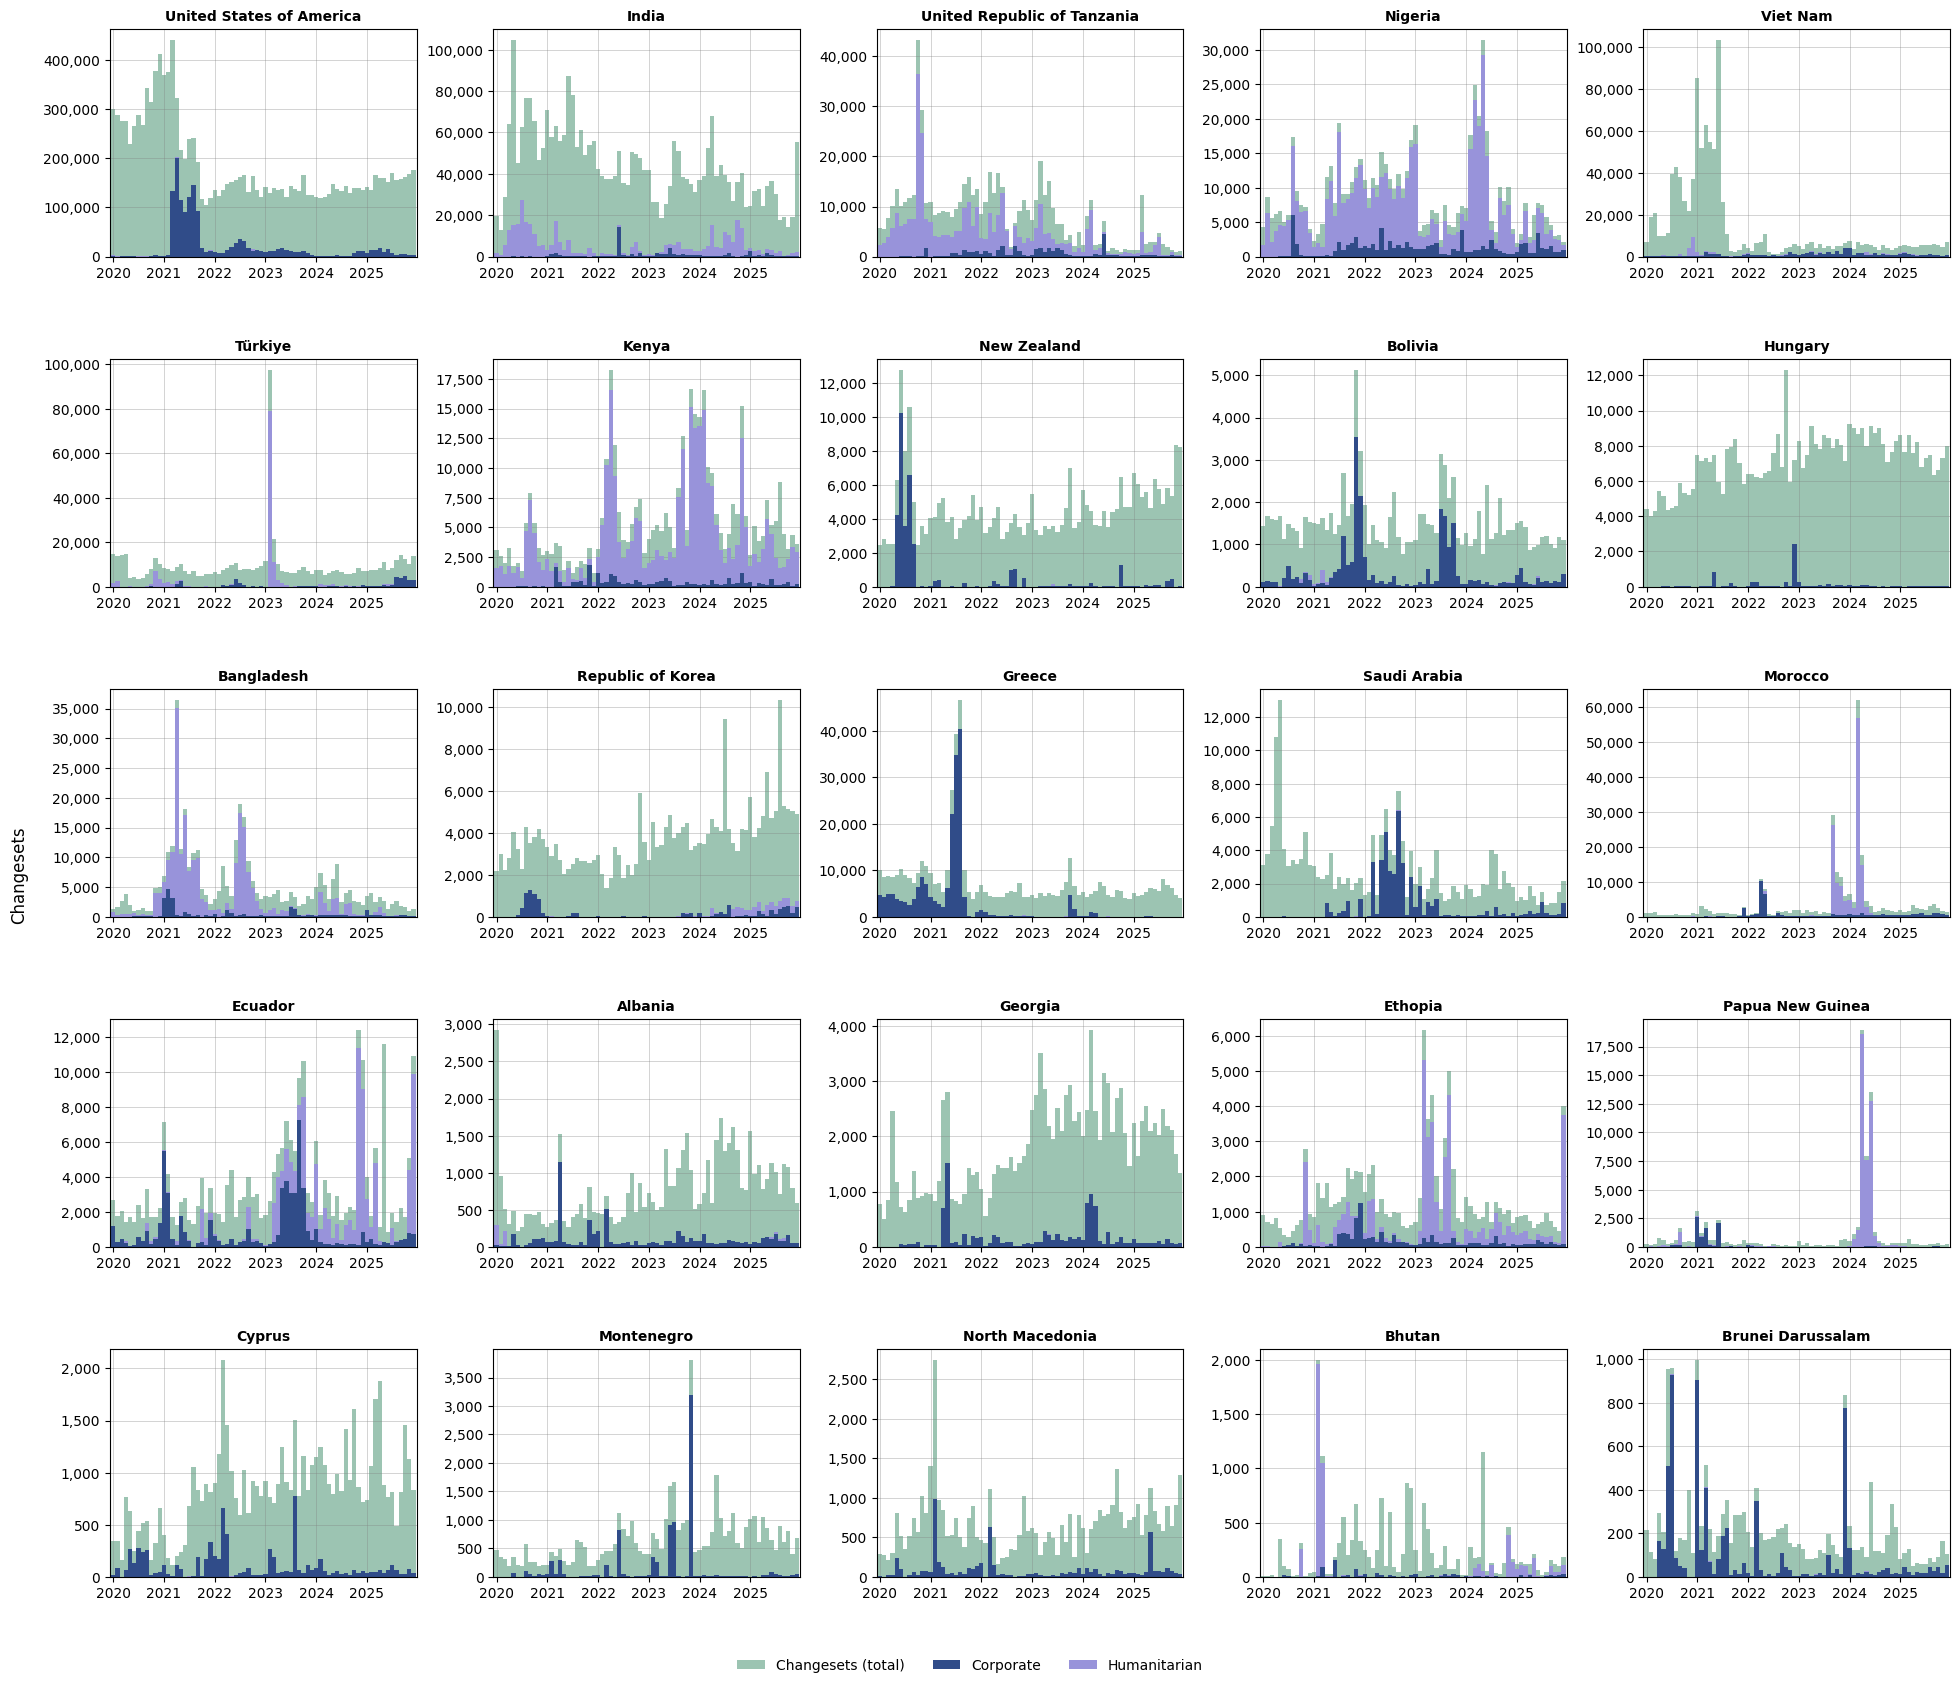

In [8]:
fig, axes = plt.subplots(5, 5,figsize=(20, 18), sharey=False)
axes = axes.flatten()


# Plot each country
for ax, (country, df) in zip(axes,dfs_total.items()):
    plot_name = plot_names.get(country, country)
    affiliation_all_plot(
        ax,
        df,
        plot_name
    )

#fig.supxlabel('Year')

fig.supylabel('Changesets')


handles, labels = axes[0].get_legend_handles_labels()

fig.legend(handles,[
        'Changesets (total)',
        'Corporate',
        'Humanitarian',
        #'AI'
    ],
    loc='lower center',
    bbox_to_anchor=(0.5, 0.05),
    ncol=4,
    frameon=False
)

plt.subplots_adjust(left=0.07, right=0.99, top=0.97, bottom=0.11, hspace=0.45, wspace=0.25)
fig.savefig("../results/top25_extra_affiliation_withoutAI.png", bbox_inches="tight")

plt.show()

#### With AI as a line 
while corporate and humanitarian anre mutually exclusive, AI is not

In [22]:
def affiliation_plot_ai_extra(ax, df, plot_name):
    df = df.copy()
    df = df.set_index('months')

    # Total changesets
    df['changesets'].plot(
        kind='bar',
        color='#9893DA',
        width=1.0,
        edgecolor='none',
        zorder=1,
        ax=ax,
        legend=False
    )

    # Affiliated changesets (stacked — mutually exclusive by construction)
    df[['changesets_corporate', 'changesets_humanitarian']].plot(
        kind='bar',
        stacked=True,
        color=['grey', '#304C89'],
        width=1.0,
        edgecolor='none',
        zorder=2,
        ax=ax,
        legend=False
    )

    # AI overlay — plotted at same integer x-positions as the bars (NOT df.index!)
    ax.plot(
        range(len(df)),
        df['changesets_AI'].values,
        color='red',
        linewidth=1.5,
        zorder=3,
        label='changesets_AI'
    )

    ax.set_title(plot_name, fontsize=10, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')

    dates = df.index
    year_positions = [i for i, date in enumerate(dates) if date.month == 1]
    year_labels = [date.strftime('%Y') for date in dates if date.month == 1]
    ax.set_xticks(year_positions)
    ax.set_xticklabels(year_labels, rotation=0)

    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    ax.grid(which='major', linewidth=0.4, color='gray', alpha=0.6)
    ax.set_ylim(bottom=0)

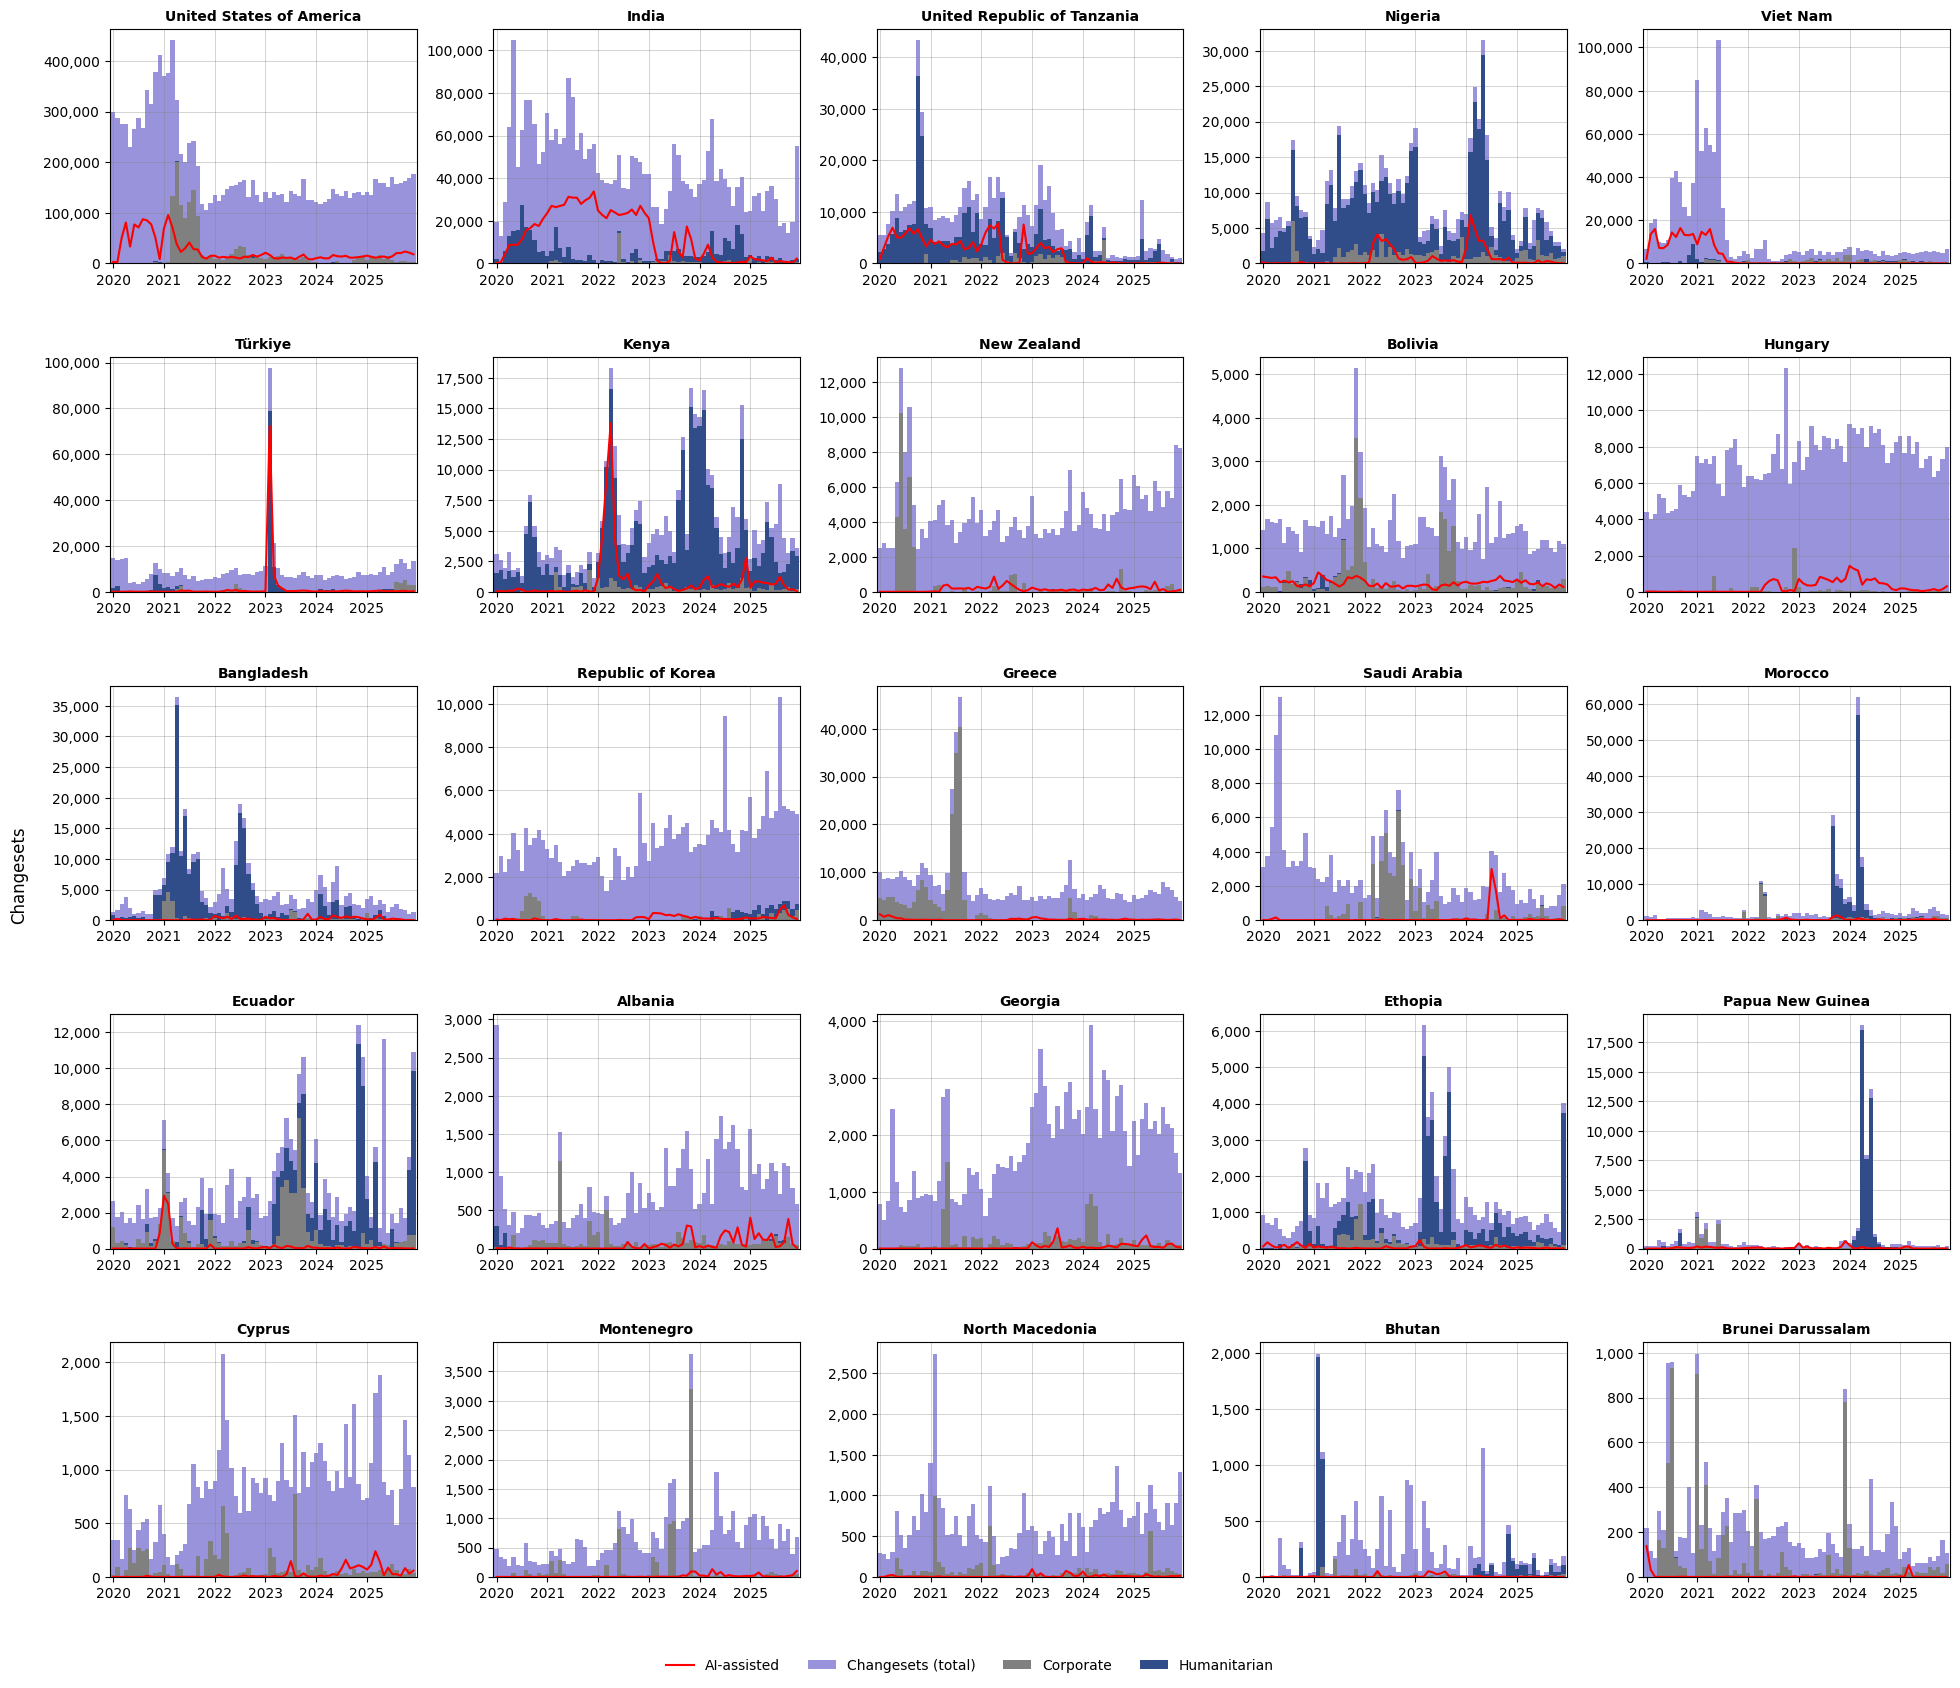

In [27]:
fig, axes = plt.subplots(5, 5,figsize=(20, 18), sharey=False)
axes = axes.flatten()


# Plot each country
for ax, (country, df) in zip(axes,dfs_total.items()):
    plot_name = plot_names.get(country, country)
    affiliation_plot_ai_extra(
        ax,
        df,
        plot_name
    )

#fig.supxlabel('Year')

fig.supylabel('Changesets')


handles, labels = axes[0].get_legend_handles_labels()

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, [
    'AI-assisted',    
    'Changesets (total)',
        'Corporate',
        'Humanitarian',
        'AI-assisted'
    ],
    loc='lower center',
    bbox_to_anchor=(0.5, 0.05),
    ncol=4,
    frameon=False
)

plt.subplots_adjust(left=0.07, right=0.99, top=0.97, bottom=0.11, hspace=0.4, wspace=0.25)
fig.savefig("../results/top25_extra_affiliation_AI_extra.png", bbox_inches="tight")

plt.show()